In [2]:
import random
import os
import seaborn as sn
print(os.getcwd())
os.chdir("/home/myshco/myenv/Proteomics")


/home/myshco/myenv/Proteomics


In [3]:

with open("peps.txt") as f:
    g = (f.readlines())
print(type(g))
sets = []
z = 0
for i in range(len(g)):
    if str(g[i])=="1\n":
        sets.append(i)
sets.append(len(g))
print(sets)
sp = []
s = set()
for i in range(len(sets)-1):
    s = set()
    li = g[sets[i]:sets[i+1]]
    pn = 1
    p2 = []
    for j in range(len(li)):
        if str(li[j])==str(pn)+"\n":
            p2.append(li[j+2][:-1])
            s = s | set((li[j+2][:-1]))
            pn+=1
    sp.append(p2)
    print(len(p2), s, len(s))

<class 'list'>
[20, 20931, 61155, 64886, 78767, 80822, 85280, 91184, 104868, 111973, 129597, 129700, 130311]
3417 {'L', 'E', 'S', 'G', 'T', 'R', 'F', 'N', 'H', 'M', 'K', 'P', 'A', 'Y', 'I', 'V', 'Q', 'W', 'D', 'C'} 20
6592 {'L', 'S', 'E', 'G', 'T', 'R', 'F', 'N', 'H', 'M', 'P', 'K', 'A', 'Y', 'I', 'V', 'Q', 'W', 'D', 'C'} 20
610 {'L', 'S', 'E', 'G', 'T', 'R', 'F', 'N', 'H', 'M', 'P', 'K', 'A', 'Y', 'I', 'V', 'Q', 'W', 'D', 'C'} 20
2270 {'L', 'S', 'E', 'G', 'T', 'R', 'F', 'N', 'H', 'M', 'K', 'P', 'A', 'Y', 'I', 'V', 'Q', 'W', 'D', 'C'} 20
333 {'L', 'S', 'E', 'G', 'T', 'R', 'F', 'N', 'H', 'M', 'P', 'K', 'A', 'Y', 'I', 'V', 'Q', 'W', 'D', 'C'} 20
726 {'L', 'S', 'E', 'G', 'T', 'R', 'F', 'N', 'H', 'M', 'P', 'K', 'A', 'Y', 'I', 'V', 'Q', 'W', 'D', 'C'} 20
966 {'L', 'E', 'S', 'G', 'T', 'R', 'F', 'N', 'H', 'M', 'P', 'K', 'A', 'Y', 'I', 'Q', 'V', 'W', 'D', 'C'} 20
2243 {'L', 'E', 'S', 'G', 'T', 'R', 'F', 'N', 'H', 'M', 'K', 'P', 'A', 'Y', 'I', 'V', 'Q', 'W', 'D', 'C'} 20
1154 {'L', 'S', 'E', 'G

In [4]:
sample_size = 500

tt = ""
for i in range(len(sp)):
    ft = "".join(g[(sets[i]-8):(sets[i]-6)])
    if len(sp[i])>sample_size:
        cho = random.sample(sp[i], sample_size)
    else:
        cho = sp[i]
    tt += ft + "\n".join(cho) + "\n\n"
    print(ft)
#print(tt)
file = open("peptideSamples.txt", "w")
file.write(tt)
file.close()

A) Identified peptide sequences from GR-LCL
GR-LCL EThcD 2D – spliced peptides


GR-LCL EThcD 2D – non-spliced peptides


GR-LCL EThcD 1D – spliced peptides


GR-LCL EThcD 1D – non-spliced peptides


GR-LCL HCD 1D – spliced peptides


GR-LCL HCD 1D – non-spliced peptides

B) Identified sequences from C1R
C1R EThcD 1D – spliced peptides


C1R EThcD 1D – non-spliced peptides

C) Identified peptide sequences from human primary fibroblasts
Fibroblasts HCD 1D – spliced peptides


Fibroblasts HCD 1D – non-spliced peptides

D) Identified Sequences from T2 cell line
T2 EThcD 1D – spliced peptides


T2 EThcD 1D – non-spliced peptides



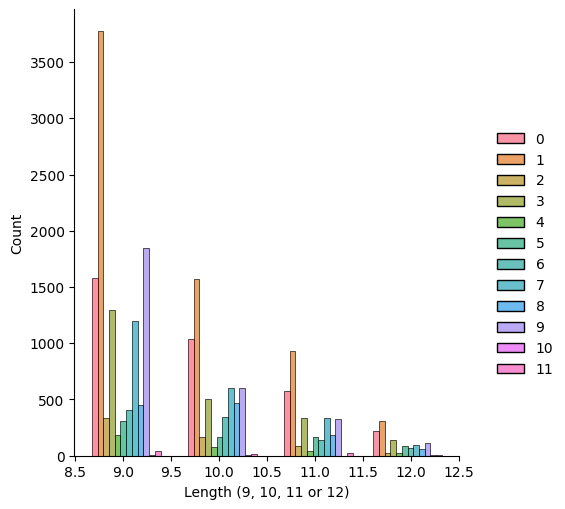

In [5]:
datas = []
disd = []
for i in range(len(sp)):
    si = {9:0, 10:0, 11:0, 12:0}
    ndisd = []
    for j in sp[i]:
        si[len(j)] += 1
        ndisd.append(len(j))
    datas.append(si)
    disd.append(ndisd)


p = sn.displot(data=disd, multiple="dodge", shrink=10)
p.set(xlabel="Length (9, 10, 11 or 12)")

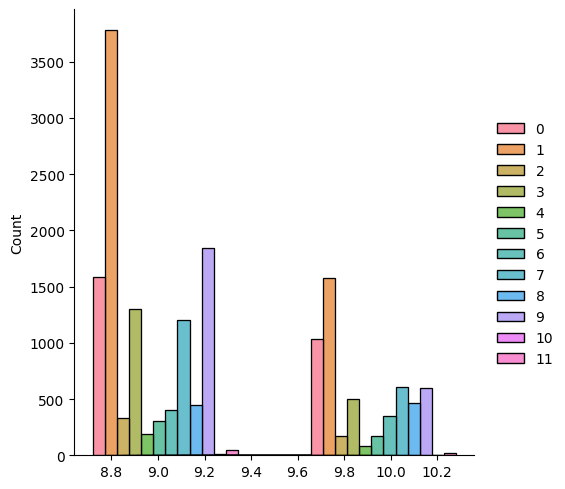

In [6]:
## filter
filtered = []
for i in range(len(sp)):
    ta = []
    for j in range(len(sp[i])):
        if len(sp[i][j])<11: ### only 9 or 10 peptides
            ta.append(sp[i][j])
    filtered.append(ta)

datas = []
disd = []
for i in range(len(filtered)):
    si = {9:0, 10:0, 11:0, 12:0}
    ndisd = []
    for j in filtered[i]:
        si[len(j)] += 1
        ndisd.append(len(j))
    datas.append(si)
    disd.append(ndisd)

p = sn.displot(data=disd, multiple="dodge", shrink=10)

In [7]:
sample_size = 500

tt = ""
for i in range(len(filtered)):
    ft = g[sets[i]-8] + g[sets[i]-7]
    if len(filtered[i])>sample_size:
        cho = random.sample(filtered[i], sample_size)
    else:
        cho = filtered[i]
    tt += ft + "\n".join(cho) + "\n\n"

#print(tt)
file = open("peptideSamples(9-10).txt", "w")
file.write(tt)
file.close()

In [9]:
names = ["GR-LCL_EThcD_2D_spliced", "GR-LCL_EThcD_2D_non-spliced", "GR-LCL_EThcD_1D_spliced", "GR-LCL_EThcD_1D_non-spliced_peptides","GR-LCL_HCD_1D_spliced_peptides","GR-LCL_HCD_1D_non-spliced"]
for i in range(6):
    tx = ",".join(sp[i])
    file = open((names[i]+".fasta"), "w")
    file.write(tx)
    file.close()